In [59]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

In [167]:
idx = 1
coord=0
samples = PKLs[idx]['res'][0]
samples = jnp.swapaxes(samples, 0, 1)
samples = samples.reshape((samples.shape[0], samples.shape[1]*samples.shape[2], samples.shape[3], samples.shape[4]))
global_mean = samples.mean(axis=[1, 2])
global_mean = global_mean.reshape((samples.shape[0], 1, 1, samples.shape[3]))
diff0 = samples- global_mean
diff0 = diff0.reshape((diff0.shape[0], diff0.shape[1], diff0.shape[2], 1, diff0.shape[3]))
var0 = jnp.mean(diff0@jnp.swapaxes(diff0, -1, -2), axis=[2])
def fcorr(k):
    diff = samples[:,:,:-k] - global_mean
    diffk = samples[:,:,k:] - global_mean
    diff = diff.reshape((diff.shape[0], diff.shape[1], diff.shape[2], 1, diff.shape[3]))
    diffk = diffk.reshape((diffk.shape[0], diffk.shape[1], diffk.shape[2], diffk.shape[3], 1))
    prod = diff@diffk
    vark = jnp.mean(prod, axis=[2])
    corr = jnp.mean(vark/var0, axis=[-3]) 
    return corr

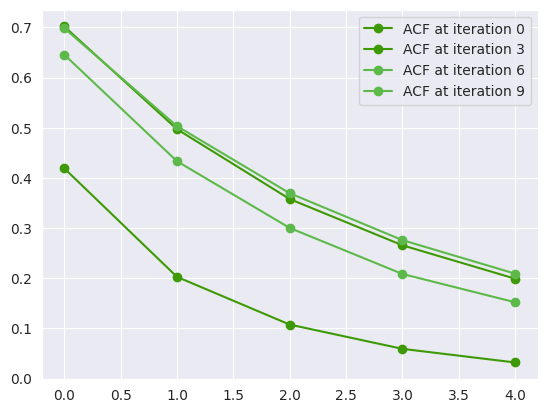

In [168]:
acfs = np.array([fcorr(k)[:,coord,coord][1:] for k in range(1, 6)])

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))
color_set = list(color_set)

for it in range(0, min(PKLs[idx]['res'][0].shape[1], 10)):
    if it % 3==0:
        plt.plot(acfs[:,it-1], marker='o',label=f"ACF at iteration {it}", color=color_set[it//5])
plt.legend()

In [155]:
PKLs[0]['res'][-2]

Array([[0.02734375, 0.05488968, 0.09180805, 0.13792717, 0.19854167,
        0.27993977, 0.3868237 , 0.5305369 , 0.71392095, 0.95530015,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [0.02734375, 0.05393982, 0.0908953 , 0.13706076, 0.19773619,
        0.2792161 , 0.38057634, 0.5209145 , 0.7005716 , 0.9438572 ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1. 

In [97]:
((samples[:,:,:,-k] - global_mean) @ jnp.swapaxes((samples[:,:,:,k:] - global_mean), -1, -2)).shape

TypeError: sub got incompatible shapes for broadcasting: (10, 36, 5000, 1), (36, 1, 1, 1).

In [128]:
PKLs[1]['config']

{'optimization_method': 'make_optimize_within_a_fixed_grid',
 'params_optimization_method': {'grid': Array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
         0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
         0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
         0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
         0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
         0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
         0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
         0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
         0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
         0.99], dtype=float32)},
 'proposal': 'build_autoregressive_gaussian_rwmh_proposal',
 'dim': 2,
 'tempering_sequence': Array([0.        , 0.02564103, 0.05128205, 0.07692308, 0.1025641 ,
        0.12820514, 0.15384616, 

In [87]:
samples.shape

(10, 36, 5000, 7, 1)

In [99]:
(samples[:,:,:-k] - global_mean).shape

(10, 36, 4999, 7, 1)